# 🎓 Library

In [1]:
# Misc
import numpy as np
import pandas as pd
import os

# Model
import tensorflow as tf
import keras
from keras.api.utils import image_dataset_from_directory
from keras.api.models import Sequential, Model
from keras.api.layers import Dense, Dropout, Conv2D, MaxPooling2D, BatchNormalization, GlobalAveragePooling2D, Input, Concatenate, UpSampling2D, SpatialDropout2D
from keras.api.optimizers import Adam
from keras.api.losses import SparseCategoricalCrossentropy

# Metrics
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Tuning
import keras_tuner as kt

# Plot
import matplotlib.pyplot as plt
import plotly.graph_objects as go

# Deactivate XLA compilation
tf.config.optimizer.set_jit(False)
# TensorFlow, check if GPU is available
if tf.config.list_physical_devices('GPU'):
    print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

2025-05-26 12:30:47.806142: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1748262647.992342      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748262648.047736      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# If the ships32 folder does not exist in data, unpack the ships.tgz file
!if [ ! -d {DATA_PATH} ]; then mkdir -p {DATA_PATH}; fi
!tar xzf {RAW_DATA}/ships.tgz -C data;


In [7]:
# Environment variables

# Either on Kaggle or local
RAW_DATA = "/kaggle/input" if os.path.exists("/kaggle/input") else f"{os.getcwd()}/data"
RAW_DATA = os.path.join(RAW_DATA, "navires-2025")

LABEL_TO_VALUE = {'coastguard':0, 'containership':1, 'corvette':2, 'cruiser':3,
           'cv':4, 'destroyer':5, 'ferry':6, 'methanier':7, 'sailing':8,
           'smallfish':9, 'submarine':10, 'tug':11, 'vsmallfish':12}

VALUE_TO_LABEL = {v: k for k, v in LABEL_TO_VALUE.items()}

BATCH_SIZE = 32
IMG_SIZE = 32
SEED = 42

DATA_PATH = f"{os.getcwd()}/data/ships32"


print(f"RAW_DATA: {RAW_DATA}")
print(f"DATA_PATH: {DATA_PATH}")

RAW_DATA: /kaggle/input/navires-2025
DATA_PATH: /kaggle/working/data/ships32


## Step 0: Extract data

Mapping should be:
```python
{'coastguard':0, 'containership':1, 'corvette':2, 'cruiser':3, 'cv':4, 'destroyer':5, 'ferry':6, 'methanier':7, 'sailing':8, 'smallfish':9, 'submarine':10, 'tug':11, 'vsmallfish':12}
```
We will use the `image_dataset_from_directory` function from `keras.utils` to get a `tf.data.Dataset` object.

Data is already batched, we take multiple images at once.

In [8]:
# Validation split depends on the subset and seed
features = {
    "directory" : DATA_PATH,
    "labels" : "inferred",
    "label_mode" : "int",
    "batch_size" : BATCH_SIZE,
    "image_size" : (IMG_SIZE, IMG_SIZE),
    "seed" : SEED
}

ds = image_dataset_from_directory(**features)

Found 48330 files belonging to 13 classes.


I0000 00:00:1748262695.900371      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Display a few of the images to check the data is loaded correctly.

In [9]:
def display_batch(batch):
    """Display a batch of images and labels."""
    
    
    for images, labels in batch:
        plt.figure(figsize=(12, 6))
        for i in range(9):
            plt.subplot(3, 3, i + 1)

            # Remove ticks and grid
            plt.xticks([])
            plt.yticks([])
            plt.grid(False)

            # Display the image
            plt.imshow(images[i].numpy().astype("uint8"))

            # Display the label
            plt.title(VALUE_TO_LABEL[labels[i].numpy()])
            
        plt.show()

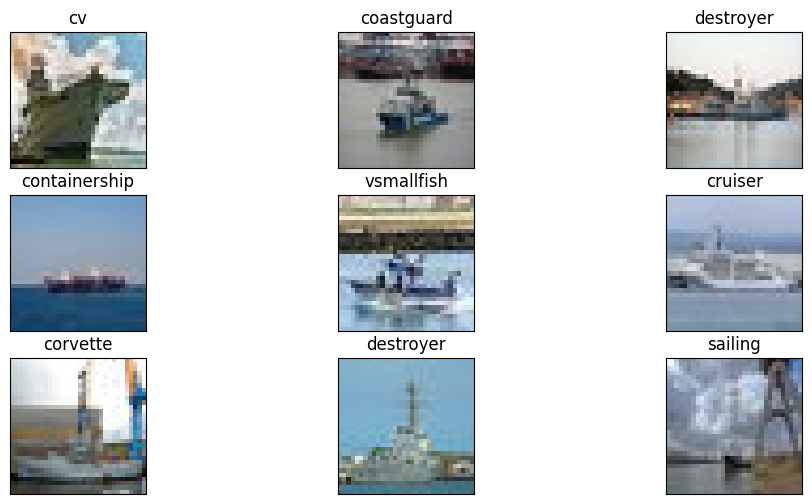

In [10]:
display_batch(ds.take(1))

## Step 1: Preprocessing

We normalize the data to be in the range [0, 1] by dividing by 255.0 (images should now be black).

### Data augmentation

zoom or crop to increase.

In [11]:
ds.cardinality().numpy() * BATCH_SIZE

48352

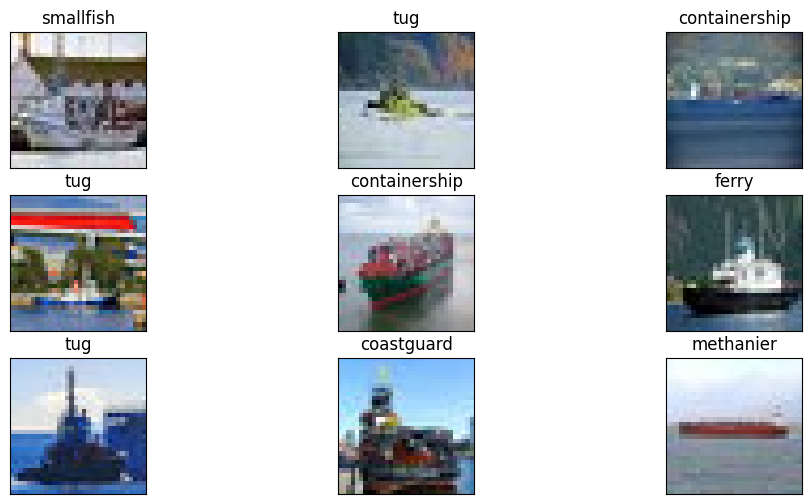

In [12]:
rotation_layer = keras.layers.RandomRotation(factor=0.05, seed=SEED)

def augment(image, label):
    image = tf.image.random_flip_left_right(image, seed=SEED)
    image = tf.image.random_hue(image, max_delta=0.05, seed=SEED)
    image = tf.image.random_brightness(image, max_delta=0.05, seed=SEED)
    return image, label

# First flip images and hue
more_images = ds.map(augment)
augmented_ds = ds.concatenate(more_images).shuffle(1000, seed=SEED)

# Then, rotate all images
more_images = ds.map(lambda x, y: (rotation_layer(x), y))
augmented_ds = augmented_ds.concatenate(more_images).shuffle(1000, seed=SEED)

display_batch(augmented_ds.take(1))

In [13]:
augmented_ds.cardinality().numpy() * BATCH_SIZE

145056

### Resize and rescale

In [14]:
def preprocess(images, labels):
    """Preprocess the images."""

    # Resize and rescale the images
    image = images / 255.0
    
    return image, labels

In [15]:
augmented_ds = augmented_ds.map(preprocess)


### Train split

In [16]:
total_count = augmented_ds.cardinality().numpy()
train_count = int(0.8 * total_count)
val_count = int(0.2 * total_count)

# Shuffle before splitting for randomness
augmented_ds = augmented_ds.shuffle(buffer_size=total_count, seed=SEED)

train_ds = augmented_ds.take(train_count)
val_ds = augmented_ds.skip(train_count).take(val_count)

In [17]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [18]:
train_ds.cardinality().numpy() * BATCH_SIZE

116032

## Step 2: Model

### Tuning hyperparameters

In [39]:
def build_model(hp):
    model = Sequential()
    model.add(Input(shape=(IMG_SIZE, IMG_SIZE, 3)))
    
    for i in range(4):  # 4 blocks
        filters = hp.Int(f"filters_{i}", min_value=32, max_value=512, step=32)
        model.add(Conv2D(filters=filters, kernel_size=3, activation="relu", padding="same"))
        model.add(BatchNormalization())
        model.add(Conv2D(filters=filters, kernel_size=3, activation="relu", padding="same"))
        model.add(BatchNormalization())
        model.add(MaxPooling2D(pool_size=2))
        model.add(SpatialDropout2D(rate=hp.Float(f"dropout_{i}", 0.1, 0.5, step=0.1)))
    
    model.add(GlobalAveragePooling2D())
    model.add(Dense(units=hp.Int("dense_units", 32, 512, step=32), activation="relu"))
    model.add(Dense(units=len(LABEL_TO_VALUE)))    
    
    model.compile(
        optimizer=Adam(learning_rate=hp.Float("lr", 1e-4, 1e-2, sampling="log")),
        loss=SparseCategoricalCrossentropy(from_logits=True),
        metrics=["accuracy"]
    )
    return model

In [40]:
tuner = kt.Hyperband(
    build_model,
    objective="val_accuracy",
    max_epochs=20,
    factor=3,
    directory="keras_tuner_dir",
    project_name="ship_model_tuning"
)


In [41]:
# Run only if you want to tune the model
tuner.search(train_ds, validation_data=val_ds, epochs=20, verbose=1)

Trial 5 Complete [00h 07m 39s]
val_accuracy: 0.8079814910888672

Best val_accuracy So Far: 0.8083954453468323
Total elapsed time: 00h 33m 32s

Search: Running Trial #6

Value             |Best Value So Far |Hyperparameter
384               |256               |filters_0
0.2               |0.2               |dropout_0
32                |512               |filters_1
0.2               |0.3               |dropout_1
384               |224               |filters_2
0.5               |0.3               |dropout_2
384               |160               |filters_3
0.4               |0.4               |dropout_3
192               |384               |dense_units
0.0025564         |0.00020286        |lr
3                 |3                 |tuner/epochs
0                 |0                 |tuner/initial_epoch
2                 |2                 |tuner/bracket
0                 |0                 |tuner/round

Epoch 1/3
3167/3626 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - accuracy: 0.3399 - loss: 2.0379

KeyboardInterrupt: 

In [ ]:
# model = tuner.get_best_models(num_models=1)[0]
# print(model.summary())

### Model A: Normal CNN
After testing some models, the following architecture has the saved hyperparameters.

In [44]:
model = Sequential([
    Conv2D(filters=256, kernel_size=(3, 3), activation="relu", padding="same", input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    BatchNormalization(),
    Conv2D(filters=256, kernel_size=(3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    SpatialDropout2D(0.2),

    Conv2D(filters=512, kernel_size=(3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    Conv2D(filters=512, kernel_size=(3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    SpatialDropout2D(0.3),

    Conv2D(filters=224, kernel_size=(3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    Conv2D(filters=224, kernel_size=(3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    SpatialDropout2D(0.3),

    Conv2D(filters=160, kernel_size=(3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    Conv2D(filters=160, kernel_size=(3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    SpatialDropout2D(0.4),
], name="ship_model")

In [45]:
output = Sequential([
    GlobalAveragePooling2D(),
    Dense(384, activation="relu"),
    Dense(len(LABEL_TO_VALUE))
], name="ship_output")

model.add(output)

In [46]:
model.compile(optimizer=Adam(learning_rate=0.00020286),
                loss=SparseCategoricalCrossentropy(from_logits=True),
                metrics=['accuracy'])

callbacks = [keras.callbacks.EarlyStopping(monitor='val_loss', patience=6, min_delta=0.0008, restore_best_weights=True, verbose=1),
             keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=4, cooldown=2, min_delta=0.0008, min_lr=1e-6, verbose=1),
             keras.callbacks.ModelCheckpoint(filepath='data/model.keras', monitor='val_loss', save_best_only=True, mode="min")]


In [47]:
print("Nombre de couches : ", len(model.layers))
model.summary()

Nombre de couches :  25


Model: "ship_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)                   │ (None, 32, 32, 256)         │           7,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_16               │ (None, 32, 32, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_17 (Conv2D)                   │ (None, 32, 32, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_17               │ (None, 32, 32, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 16, 16, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ spatial_dropout2d_8                  │ (None, 16, 16, 256)         │               0 │
│ (SpatialDropout2D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_18 (Conv2D)                   │ (None, 16, 16, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_18               │ (None, 16, 16, 512)         │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_19 (Conv2D)                   │ (None, 16, 16, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_19               │ (None, 16, 16, 512)         │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_9 (MaxPooling2D)       │ (None, 8, 8, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ spatial_dropout2d_9                  │ (None, 8, 8, 512)           │               0 │
│ (SpatialDropout2D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_20 (Conv2D)                   │ (None, 8, 8, 224)           │       1,032,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_20               │ (None, 8, 8, 224)           │             896 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_21 (Conv2D)                   │ (None, 8, 8, 224)           │         451,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_21               │ (None, 8, 8, 224)           │             896 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_10 (MaxPooling2D)      │ (None, 4, 4, 224)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 6,250,765 (23.84 MB)

 Trainable params: 6,246,157 (23.83 MB)

 Non-trainable params: 4,608 (18.00 KB)

## Model B: U-Net
The U-Net architecture consists of an encoder-decoder structure with skip connections, which allows the model to capture both high-level and low-level features in the input images.

In [23]:
# inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

# encoder_filters = [320, 256, 384]
# dropouts = [0.1, 0.3, 0.1]
# skips = []
# x = inputs

# # Encoder (Conv + BN per block)
# for filters, drop in zip(encoder_filters, dropouts):
#     x = Conv2D(filters, (3, 3), activation='relu', padding='same')(x)
#     x = BatchNormalization()(x)
#     skips.append(x)
#     x = MaxPooling2D((2, 2))(x)
#     x = Dropout(drop)(x)

# # Bottleneck
# x = Conv2D(384, (3, 3), activation='relu', padding='same')(x)
# x = BatchNormalization()(x)

# # Decoder
# for filters, skip in zip(reversed(encoder_filters), reversed(skips)):
#     x = UpSampling2D((2, 2))(x)
#     x = Concatenate()([x, skip])
#     x = Conv2D(filters, (3, 3), activation='relu', padding='same')(x)
#     x = BatchNormalization()(x)

# # Output head
# x = GlobalAveragePooling2D()(x)
# x = Dense(288, activation="relu")(x)
# outputs = Dense(len(LABEL_TO_VALUE))(x)

# model = Model(inputs=inputs, outputs=outputs, name="ship_unet_bn")

# model.compile(
#     optimizer=Adam(learning_rate=0.00025431),
#     loss=SparseCategoricalCrossentropy(from_logits=True),
#     metrics=['accuracy']
# )


## Step 3: Training & Evaluation

In [48]:
hist = model.fit(train_ds, validation_data=val_ds, epochs=45, callbacks=callbacks, verbose=1)

Epoch 1/45
3626/3626 ━━━━━━━━━━━━━━━━━━━━ 132s 33ms/step - accuracy: 0.3958 - loss: 1.8292 - val_accuracy: 0.6626 - val_loss: 0.9707 - learning_rate: 2.0286e-04
Epoch 2/45
3626/3626 ━━━━━━━━━━━━━━━━━━━━ 112s 31ms/step - accuracy: 0.6772 - loss: 0.9456 - val_accuracy: 0.7476 - val_loss: 0.7205 - learning_rate: 2.0286e-04
Epoch 3/45
3626/3626 ━━━━━━━━━━━━━━━━━━━━ 113s 31ms/step - accuracy: 0.7501 - loss: 0.7129 - val_accuracy: 0.8075 - val_loss: 0.5458 - learning_rate: 2.0286e-04
Epoch 4/45
3626/3626 ━━━━━━━━━━━━━━━━━━━━ 113s 31ms/step - accuracy: 0.8027 - loss: 0.5617 - val_accuracy: 0.8334 - val_loss: 0.4661 - learning_rate: 2.0286e-04
Epoch 5/45
3626/3626 ━━━━━━━━━━━━━━━━━━━━ 112s 31ms/step - accuracy: 0.8359 - loss: 0.4612 - val_accuracy: 0.8623 - val_loss: 0.3952 - learning_rate: 2.0286e-04
Epoch 6/45
3626/3626 ━━━━━━━━━━━━━━━━━━━━ 112s 31ms/step - accuracy: 0.8634 - loss: 0.3818 - val_accuracy: 0.8549 - val_loss: 0.4288 - learning_rate: 2.0286e-04
Epoch 7/45
3626/3626 ━━━━━━━━━━━━━

In [49]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    y=hist.history["val_loss"],
    mode="lines",
    name="Validation Loss"
))

fig.add_trace(go.Scatter(
    y=hist.history["loss"],
    mode="lines",
    name="Train Loss"
))

fig.update_layout(
    title="Validation loss per epoch",
    xaxis_title="Epoch",
    yaxis_title="Loss",
    legend_title="Dataset",
    xaxis=dict(tickmode="linear"),
)

### Loading and evaluating the model

In [26]:
model = keras.models.load_model("data/best_model.keras")

ValueError: File not found: filepath=data/best_model.keras. Please ensure the file is an accessible `.keras` zip file.

In [50]:
test_loss, test_acc = model.evaluate(val_ds, verbose=2)

906/906 - 8s - 9ms/step - accuracy: 0.9613 - loss: 0.1525


In [51]:
print(f"Test accuracy: {test_acc}")
print(f"Test loss: {test_loss}")

Test accuracy: 0.9612652063369751
Test loss: 0.15250593423843384


In [52]:
y_pred = model.predict(train_ds).argmax(axis=1)

3626/3626 ━━━━━━━━━━━━━━━━━━━━ 35s 9ms/step


In [53]:
y_labels = []
for image, label in train_ds.unbatch():
    y_labels.append(int(label.numpy()))

In [54]:
report = classification_report(y_pred, y_labels, target_names=VALUE_TO_LABEL.values())
print(report)

               precision    recall  f1-score   support

   coastguard       1.00      1.00      1.00      7908
containership       1.00      1.00      1.00     15682
     corvette       1.00      1.00      1.00      6942
      cruiser       1.00      1.00      1.00     15757
           cv       1.00      1.00      1.00      4709
    destroyer       1.00      1.00      1.00     14898
        ferry       1.00      1.00      1.00      7945
    methanier       1.00      1.00      1.00      8119
      sailing       1.00      1.00      1.00      4074
    smallfish       1.00      1.00      1.00      7739
    submarine       1.00      1.00      1.00      6417
          tug       1.00      1.00      1.00      7970
   vsmallfish       1.00      1.00      1.00      7850

     accuracy                           1.00    116010
    macro avg       1.00      1.00      1.00    116010
 weighted avg       1.00      1.00      1.00    116010



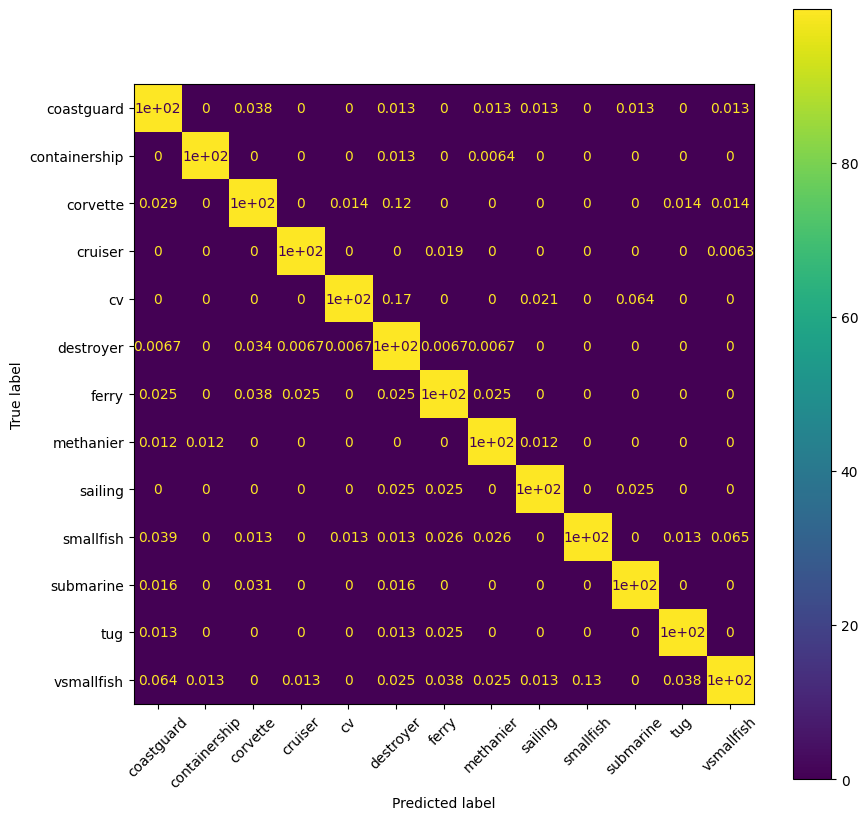

In [55]:
cm = confusion_matrix(y_labels, y_pred, labels=list(LABEL_TO_VALUE.values()))
cm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis] * 100

heat = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=VALUE_TO_LABEL.values())
fig, ax = plt.subplots(figsize=(10, 10))

heat.plot(ax=ax)
plt.xticks(rotation=45)
plt.show()

# Results

In [56]:
X_test = np.load(f"{RAW_DATA}/ships_competition.npz", allow_pickle=True)['X']
X_test = X_test.astype('float32') / 255

In [57]:
res = model.predict(X_test).argmax(axis=1)
df = pd.DataFrame({"Category":res})
df.to_csv("data/reco_nav.csv", index_label="Id")

63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step


In [59]:
!head data/reco_nav.csv

Id,Category
0,5
1,3
2,8
3,6
4,5
5,0
6,1
7,1
8,3


In [61]:
from IPython.display import FileLink
FileLink(r'data/reco_nav.csv')

/kaggle/working/data/reco_nav.csv